# TemporalWiki Dataset Exploration

This notebook walks through a thorough exploration of the TemporalWiki dataset, which we will use as the foundation for our *Contradiction-Aware Sparse Memory Finetuning* continual learning project.

### Dataset Overview
TemporalWiki consists of two main components:
- **TWiki_Diffsets** â€” Raw Wikipedia text diffs between consecutive monthly snapshots (Augâ€“Dec 2020). This is our **training signal**.
- **TWiki_Probes** â€” Structured Wikidata triples (subject, relation, object) used for **evaluation**. Each snapshot has a `changed` and `unchanged` split.

### What We Want to Understand
1. What does the raw diff text look like, and how long are the passages?
2. What do the probe triples look like â€” how many, what relations, what subjects?
3. How many facts *changed* vs *stayed the same* per snapshot?
4. What does a contradiction look like in this dataset?
5. Are there data quality issues we need to handle?

---

## Setup

Install dependencies using [uv](https://github.com/astral-sh/uv):
```bash
uv pip install pandas matplotlib
```

## Imports

In [5]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import os

print("pandas:", pd.__version__)

# Paths
DIFFSETS_ZIP = "data/TWiki_Diffsets.zip"
PROBES_ZIP   = "data/TWiki_Probes.zip"

assert os.path.exists(DIFFSETS_ZIP), f"Missing {DIFFSETS_ZIP}"
assert os.path.exists(PROBES_ZIP),   f"Missing {PROBES_ZIP}"
print("Both zip files found.")

pandas: 2.3.3
Both zip files found.


---
## 1. Inspect Zip Contents

Before loading any data, list every file inside each zip.

In [6]:
for zip_path in [DIFFSETS_ZIP, PROBES_ZIP]:
    print(f"\n{'='*55}")
    print(f"  {zip_path}")
    print(f"{'='*55}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            size_kb = info.file_size / 1024
            print(f"  {info.filename:<50}  {size_kb:>8.1f} KB")


  data/TWiki_Diffsets.zip
  TWiki_Diffsets/                                          0.0 KB
  TWiki_Diffsets/wikipedia_0910_gpt2.csv              1079660.2 KB
  TWiki_Diffsets/wikipedia_0809_gpt2.csv              1076784.5 KB
  TWiki_Diffsets/wikipedia_1011_gpt2.csv              1073507.8 KB
  TWiki_Diffsets/wikipedia_1112_gpt2.csv              1153916.9 KB

  data/TWiki_Probes.zip
  twiki_probes/                                            0.0 KB
  twiki_probes/.DS_Store                                   6.0 KB
  twiki_probes/0801-0901_changed.csv                      77.2 KB
  twiki_probes/0801-0901_unchanged.csv                   304.1 KB
  twiki_probes/0901-1001_changed.csv                      86.2 KB
  twiki_probes/0901-1001_unchanged.csv                   324.1 KB
  twiki_probes/1001-1101_changed.csv                      56.7 KB
  twiki_probes/1001-1101_unchanged.csv                   324.6 KB
  twiki_probes/1101-1201_changed.csv                      84.8 KB
  twiki_probes/1101-

---
## 2. Load All Diffsets

The diffsets are the training data. They are raw Wikipedia text passages that changed between consecutive monthly snapshots.

Load all four into a dictionary keyed by snapshot period (e.g. `'0809'` = Aug->Sep).

In [7]:
diffset_files = {
    "0809": "TWiki_Diffsets/wikipedia_0809_gpt2.csv",
    "0910": "TWiki_Diffsets/wikipedia_0910_gpt2.csv",
    "1011": "TWiki_Diffsets/wikipedia_1011_gpt2.csv",
    "1112": "TWiki_Diffsets/wikipedia_1112_gpt2.csv",
}

diffsets = {}
with zipfile.ZipFile(DIFFSETS_ZIP, 'r') as z:
    for key, path in diffset_files.items():
        with z.open(path) as f:
            diffsets[key] = pd.read_csv(f)

for key, df in diffsets.items():
    print(f"Diffset {key}: {len(df):,} rows | columns: {list(df.columns)}")

Diffset 0809: 808,867 rows | columns: ['text']
Diffset 0910: 806,485 rows | columns: ['text']
Diffset 1011: 809,383 rows | columns: ['text']
Diffset 1112: 896,218 rows | columns: ['text']


---
## 3. Explore Diffset Text

Each row is a long Wikipedia passage. Look at a few examples and understand the text length distribution, which will matters a lot when we chunk for fine-tuning.

In [8]:
# Show 3 sample passages from the first diffset
df = diffsets["0809"]

for i, row in df.head(3).iterrows():
    text = row['text']
    print(f"\n--- Row {i} (first 500 chars) ---")
    print(text[:500])
    print(f"  [total length: {len(text)} chars]")


--- Row 0 (first 500 chars) ---
Anarchism. The etymological origin of "anarchism" is from the Ancient Greek "anarkhia", meaning "without a ruler", composed of the prefix "an-" ("without") and the word "arkhos" ("leader" or "ruler").  Many revolutionaries of the 19th century such as William Godwin (1756–1836) and Wilhelm Weitling (1808–1871) would contribute to the anarchist doctrines of the next generation but did not use "anarchist" or "anarchism" in describing themselves or their beliefs.  Some usages of "libertarianism" ref
  [total length: 2522 chars]

--- Row 1 (first 500 chars) ---
, they met harsh suppression after the Bolshevik government was stabilised.  The Soviet Union provided some limited assistance at the beginning of the war, but the result was a bitter fight among communists and anarchists at a series of events named May Days as Joseph Stalin tried to seise control of the Republicans.  The 1960s witnessed a revival of anarchism, likely caused by a perceived failure of 

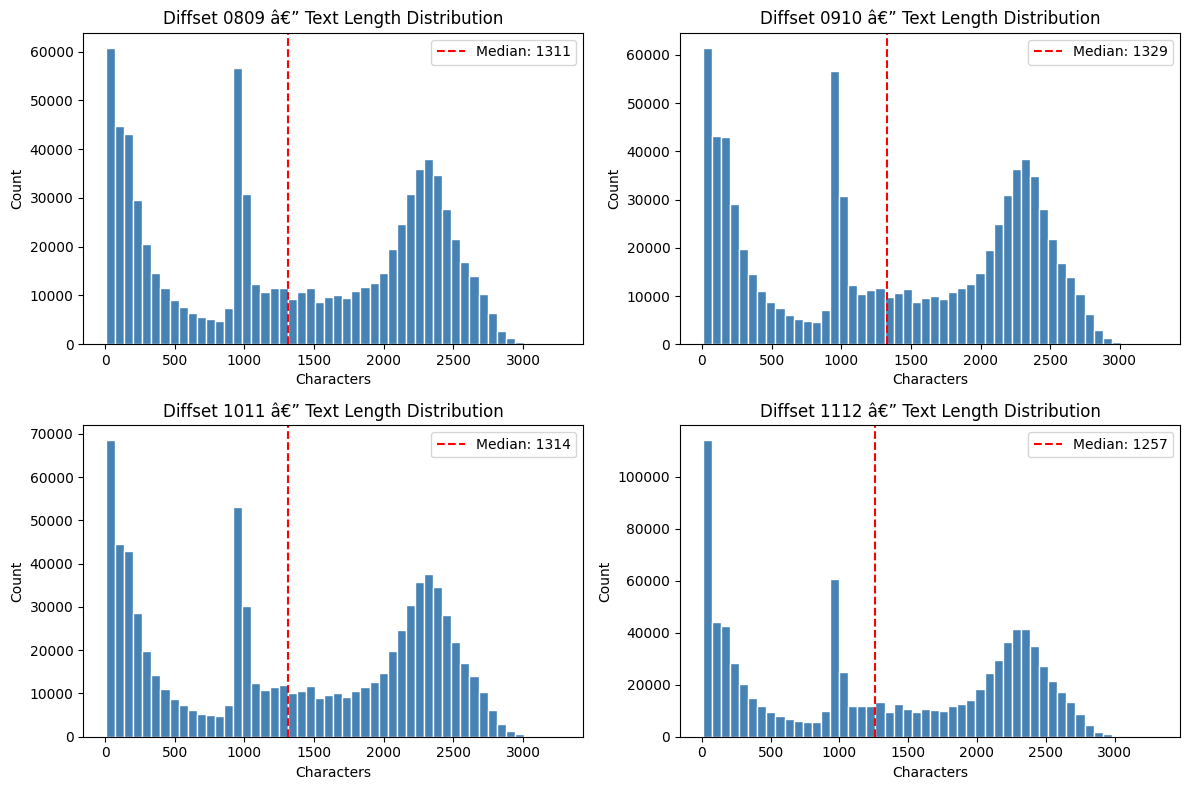

In [9]:
# Text length distribution across all diffsets
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (key, df) in enumerate(diffsets.items()):
    lengths = df['text'].str.len()
    axes[i].hist(lengths, bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f"Diffset {key} â€” Text Length Distribution")
    axes[i].set_xlabel("Characters")
    axes[i].set_ylabel("Count")
    axes[i].axvline(lengths.median(), color='red', linestyle='--', label=f"Median: {lengths.median():.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics for text lengths
print(f"{'Snapshot':<12} {'Count':>8} {'Min':>8} {'Median':>10} {'Mean':>10} {'Max':>10}")
print("-" * 60)
for key, df in diffsets.items():
    lengths = df['text'].str.len()
    print(f"{key:<12} {len(df):>8,} {lengths.min():>8,} {lengths.median():>10,.0f} {lengths.mean():>10,.0f} {lengths.max():>10,}")

Snapshot        Count      Min     Median       Mean        Max
------------------------------------------------------------
0809          808,867        6      1,311      1,341      3,268
0910          806,485        6      1,329      1,349      3,268
1011          809,383        6      1,314      1,336      3,268
1112          896,218        6      1,257      1,298      3,311


---
## 4. Load All Probes

The probes are structured **Wikidata triples** used for evaluation. Each snapshot has two files:
- `changed` : facts that were **updated** in that snapshot (these are our contradiction pairs)
- `unchanged` : facts that **stayed the same** (these test knowledge retention)

Load all 8 files into a nested dictionary.

In [11]:
probe_files = {
    "0801-0901": {"changed": "twiki_probes/0801-0901_changed.csv",   "unchanged": "twiki_probes/0801-0901_unchanged.csv"},
    "0901-1001": {"changed": "twiki_probes/0901-1001_changed.csv",   "unchanged": "twiki_probes/0901-1001_unchanged.csv"},
    "1001-1101": {"changed": "twiki_probes/1001-1101_changed.csv",   "unchanged": "twiki_probes/1001-1101_unchanged.csv"},
    "1101-1201": {"changed": "twiki_probes/1101-1201_changed.csv",   "unchanged": "twiki_probes/1101-1201_unchanged.csv"},
}

probes = {}
with zipfile.ZipFile(PROBES_ZIP, 'r') as z:
    for period, splits in probe_files.items():
        probes[period] = {}
        for split, path in splits.items():
            with z.open(path) as f:
                probes[period][split] = pd.read_csv(f)

for period, splits in probes.items():
    for split, df in splits.items():
        print(f"Probe {period} [{split:>9}]: {len(df):,} rows | columns: {list(df.columns)}")

Probe 0801-0901 [  changed]: 1,776 rows | columns: ['subject', 'relation', 'object']
Probe 0801-0901 [unchanged]: 6,935 rows | columns: ['subject', 'relation', 'object']
Probe 0901-1001 [  changed]: 1,982 rows | columns: ['subject', 'relation', 'object']
Probe 0901-1001 [unchanged]: 7,340 rows | columns: ['subject', 'relation', 'object']
Probe 1001-1101 [  changed]: 1,358 rows | columns: ['subject', 'relation', 'object']
Probe 1001-1101 [unchanged]: 7,313 rows | columns: ['subject', 'relation', 'object']
Probe 1101-1201 [  changed]: 1,951 rows | columns: ['subject', 'relation', 'object']
Probe 1101-1201 [unchanged]: 7,293 rows | columns: ['subject', 'relation', 'object']


---
## 5. Explore Probe Triples

Each probe row is a `(subject, relation, object)` triple.

In [12]:
# Sample rows from changed and unchanged probes
for split in ["changed", "unchanged"]:
    print(f"\n--- {split.upper()} probes (0801-0901) ---")
    print(probes["0801-0901"][split].head(10).to_string(index=False))


--- CHANGED probes (0801-0901) ---
             subject               relation               object
   Nagpur Metro Rail               has part       Congress Nagar
     Come and Get It               composer       Paul McCartney
     Kool & The Gang               has part          Ronald Bell
Turnberry Lighthouse                  color                white
   instant messaging            subclass of             software
      Folsom Library                part of Rensselaer Libraries
       Medtronic plc               replaces          Omar Ishrak
             Taliban            chairperson       Akhtar Mansour
              Queens   determination method               census
     Mangkunegara IX country of citizenship            Indonesia

--- UNCHANGED probes (0801-0901) ---
                 subject              relation           object
                    Zola           instance of         business
               Henry VII        place of birth  Pembroke Castle
     Flamingoes in 

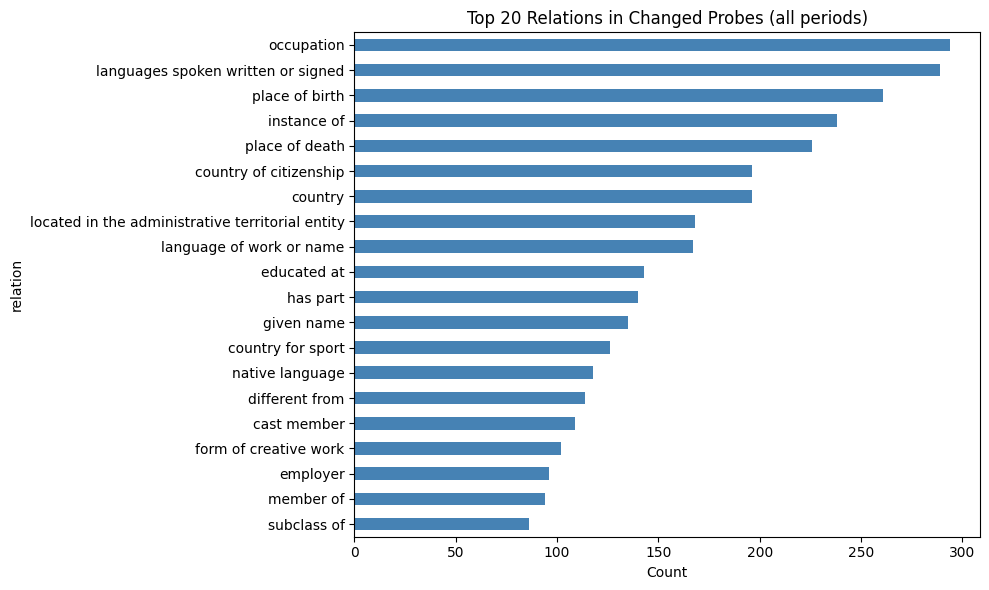


Total unique relations: 351


In [13]:
# Most frequent relations in changed probes across all periods
all_changed = pd.concat([probes[p]["changed"] for p in probes], ignore_index=True)

relation_counts = all_changed['relation'].value_counts().head(20)

plt.figure(figsize=(10, 6))
relation_counts.plot(kind='barh', color='steelblue')
plt.title("Top 20 Relations in Changed Probes (all periods)")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal unique relations: {all_changed['relation'].nunique()}")

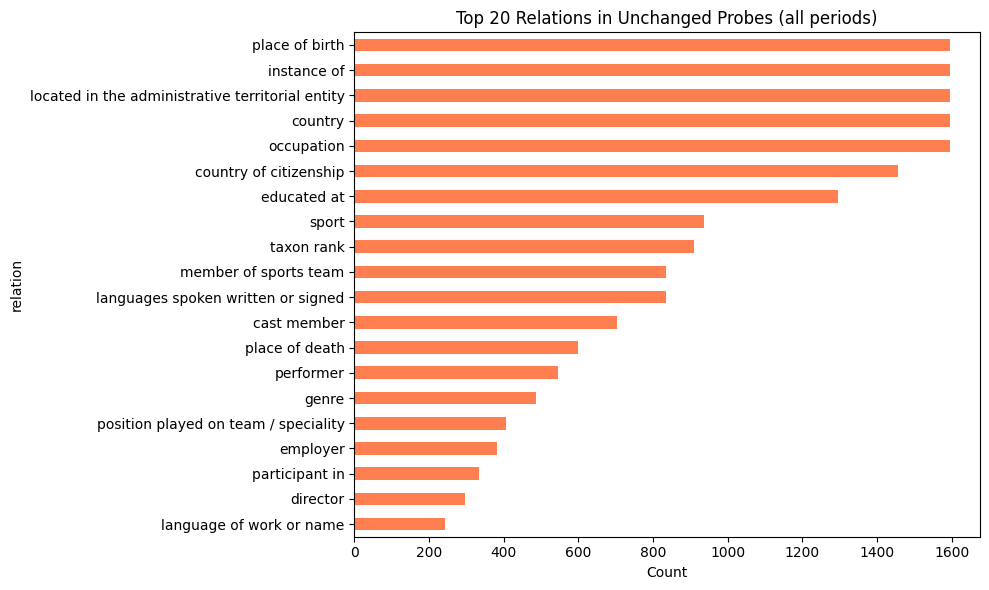

In [14]:
# Most frequent relations in unchanged probes
all_unchanged = pd.concat([probes[p]["unchanged"] for p in probes], ignore_index=True)

relation_counts_unch = all_unchanged['relation'].value_counts().head(20)

plt.figure(figsize=(10, 6))
relation_counts_unch.plot(kind='barh', color='coral')
plt.title("Top 20 Relations in Unchanged Probes (all periods)")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Changed vs Unchanged: Size Comparison

This tells us how much of the knowledge base changes per snapshot, which is directly relevant to how many contradiction pairs we'll have to work with.

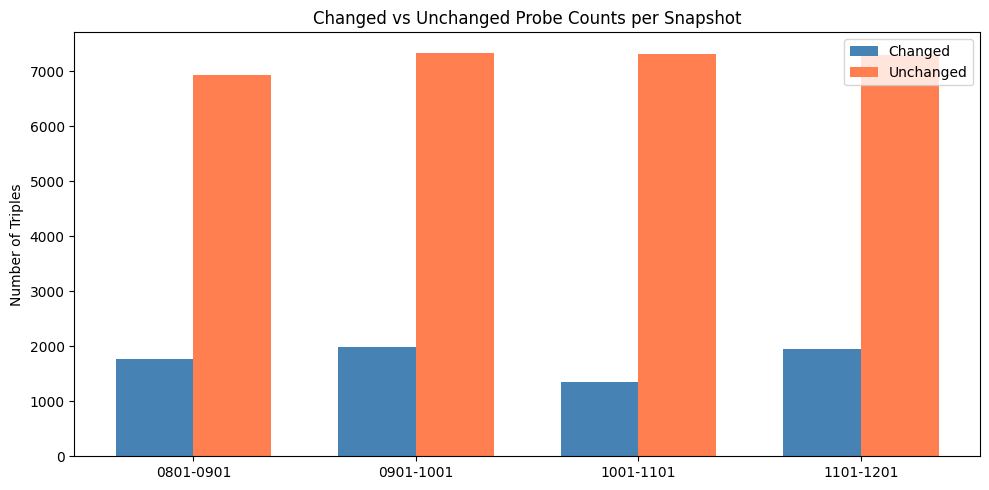


Period             Changed    Unchanged    % Changed
----------------------------------------------------
0801-0901            1,776        6,935        20.4%
0901-1001            1,982        7,340        21.3%
1001-1101            1,358        7,313        15.7%
1101-1201            1,951        7,293        21.1%


In [15]:
periods = list(probes.keys())
changed_counts   = [len(probes[p]["changed"])   for p in periods]
unchanged_counts = [len(probes[p]["unchanged"]) for p in periods]

x = range(len(periods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], changed_counts,   width, label='Changed',   color='steelblue')
ax.bar([i + width/2 for i in x], unchanged_counts, width, label='Unchanged', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(periods)
ax.set_title("Changed vs Unchanged Probe Counts per Snapshot")
ax.set_ylabel("Number of Triples")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{'Period':<15} {'Changed':>10} {'Unchanged':>12} {'% Changed':>12}")
print("-" * 52)
for p, c, u in zip(periods, changed_counts, unchanged_counts):
    pct = 100 * c / (c + u)
    print(f"{p:<15} {c:>10,} {u:>12,} {pct:>11.1f}%")

---
## 7. Contradiction Structure

A key challenge for our project: the `changed` probes give us the **new** fact, but not the **old** one. 

However, if a subject-relation pair appears in an **earlier** period's unchanged probes and a **later** period's changed probes, we can reconstruct the contradiction: old object â†’ new object.

Let's check how many such pairs we can recover.

In [16]:
period_keys = list(probes.keys())  # [0801-0901, 0901-1001, 1001-1101, 1101-1201]

# â”€â”€ 1. Check cross-period (subject, relation) overlap at all â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("=" * 60)
print("1. (subject, relation) overlap across ALL period pairs")
print("=" * 60)

for i, p1 in enumerate(period_keys):
    for j, p2 in enumerate(period_keys):
        if j <= i:
            continue
        sr1 = set(zip(probes[p1]["unchanged"]["subject"], probes[p1]["unchanged"]["relation"]))
        sr2 = set(zip(probes[p2]["changed"]["subject"],   probes[p2]["changed"]["relation"]))
        overlap = sr1 & sr2
        print(f"  unchanged({p1}) âˆ© changed({p2}): {len(overlap):,} pairs")

# â”€â”€ 2. Check if subject pools even overlap between periods â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "=" * 60)
print("2. Subject overlap between changed probe periods")
print("=" * 60)

for i in range(len(period_keys) - 1):
    s1 = set(probes[period_keys[i]]["changed"]["subject"])
    s2 = set(probes[period_keys[i+1]]["changed"]["subject"])
    print(f"  changed({period_keys[i]}) âˆ© changed({period_keys[i+1]}): {len(s1 & s2):,} subjects")

print()
for i in range(len(period_keys) - 1):
    s1 = set(probes[period_keys[i]]["unchanged"]["subject"])
    s2 = set(probes[period_keys[i+1]]["unchanged"]["subject"])
    print(f"  unchanged({period_keys[i]}) âˆ© unchanged({period_keys[i+1]}): {len(s1 & s2):,} subjects")

# â”€â”€ 3. Check if same subject appears as unchanged then changed â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "=" * 60)
print("3. Subjects appearing as UNCHANGED then later CHANGED")
print("=" * 60)

for i in range(len(period_keys) - 1):
    early, late = period_keys[i], period_keys[i+1]
    s_unchanged = set(probes[early]["unchanged"]["subject"])
    s_changed   = set(probes[late]["changed"]["subject"])
    overlap = s_unchanged & s_changed
    print(f"  {early} unchanged â†’ {late} changed: {len(overlap):,} subjects")
    if len(overlap) > 0:
        # Show a few examples
        sample = list(overlap)[:3]
        for subj in sample:
            old_rows = probes[early]["unchanged"][probes[early]["unchanged"]["subject"] == subj]
            new_rows = probes[late]["changed"][probes[late]["changed"]["subject"] == subj]
            print(f"\n    Subject: '{subj}'")
            print(f"      unchanged facts: {old_rows[['relation','object']].values.tolist()}")
            print(f"      changed  facts:  {new_rows[['relation','object']].values.tolist()}")

# â”€â”€ 4. Fuzzy check â€” are subjects failing due to whitespace/case? â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "=" * 60)
print("4. Sanity check â€” whitespace or case mismatches in subjects?")
print("=" * 60)

for period in period_keys:
    for split in ["changed", "unchanged"]:
        df = probes[period][split]
        has_leading  = (df["subject"] != df["subject"].str.strip()).sum()
        has_upper    = (df["subject"] != df["subject"].str.lower()).sum()
        print(f"  {period} [{split:>9}]: leading_whitespace={has_leading}, mixed_case_subjects={has_upper}")

# â”€â”€ 5. Summary diagnosis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "=" * 60)
print("5. Diagnosis summary")
print("=" * 60)

all_unchanged_subjects = set()
all_changed_subjects   = set()
for p in period_keys:
    all_unchanged_subjects |= set(probes[p]["unchanged"]["subject"])
    all_changed_subjects   |= set(probes[p]["changed"]["subject"])

total_overlap = all_unchanged_subjects & all_changed_subjects
print(f"  Subjects ever in unchanged: {len(all_unchanged_subjects):,}")
print(f"  Subjects ever in changed:   {len(all_changed_subjects):,}")
print(f"  Subjects appearing in both (across any period): {len(total_overlap):,}")
print()
if len(total_overlap) == 0:
    print("  âœ— CONCLUSION: Subject pools are completely disjoint.")
    print("    The dataset was likely sampled so changed/unchanged never share entities.")
    print("    Cross-period merge cannot recover contradictions from probes alone.")
    print("    â†’ Next step: extract old facts from diffset text using the changed probes as anchors.")
else:
    print(f"  âœ“ Overlap exists â€” contradiction recovery may be possible.")
    print(f"    Re-examine merge logic or normalise subject strings.")

1. (subject, relation) overlap across ALL period pairs
  unchanged(0801-0901) âˆ© changed(0901-1001): 0 pairs
  unchanged(0801-0901) âˆ© changed(1001-1101): 1 pairs
  unchanged(0801-0901) âˆ© changed(1101-1201): 1 pairs
  unchanged(0901-1001) âˆ© changed(1001-1101): 0 pairs
  unchanged(0901-1001) âˆ© changed(1101-1201): 0 pairs
  unchanged(1001-1101) âˆ© changed(1101-1201): 0 pairs

2. Subject overlap between changed probe periods
  changed(0801-0901) âˆ© changed(0901-1001): 16 subjects
  changed(0901-1001) âˆ© changed(1001-1101): 19 subjects
  changed(1001-1101) âˆ© changed(1101-1201): 11 subjects

  unchanged(0801-0901) âˆ© unchanged(0901-1001): 42 subjects
  unchanged(0901-1001) âˆ© unchanged(1001-1101): 53 subjects
  unchanged(1001-1101) âˆ© unchanged(1101-1201): 54 subjects

3. Subjects appearing as UNCHANGED then later CHANGED
  0801-0901 unchanged â†’ 0901-1001 changed: 5 subjects

    Subject: 'Andrej Babiš'
      unchanged facts: [['applies to jurisdiction', 'Bohemia']]
      

---
## 8. Data Quality Checks

Before using this data for training, we need to check for:
- Null / empty values
- Duplicate rows
- Very short text passages that might be noise

In [17]:
print("=== DIFFSET NULL CHECKS ===")
for key, df in diffsets.items():
    nulls = df.isnull().sum().sum()
    empty = (df['text'].str.strip() == '').sum()
    dupes = df.duplicated().sum()
    print(f"  {key}: nulls={nulls}, empty_strings={empty}, duplicates={dupes}")

print("\n=== PROBE NULL CHECKS ===")
for period, splits in probes.items():
    for split, df in splits.items():
        nulls = df.isnull().sum().sum()
        dupes = df.duplicated().sum()
        print(f"  {period} [{split:>9}]: nulls={nulls}, duplicates={dupes}")

=== DIFFSET NULL CHECKS ===
  0809: nulls=0, empty_strings=0, duplicates=35533
  0910: nulls=0, empty_strings=0, duplicates=35851
  1011: nulls=0, empty_strings=0, duplicates=34700
  1112: nulls=0, empty_strings=0, duplicates=34420

=== PROBE NULL CHECKS ===
  0801-0901 [  changed]: nulls=0, duplicates=0
  0801-0901 [unchanged]: nulls=0, duplicates=0
  0901-1001 [  changed]: nulls=0, duplicates=0
  0901-1001 [unchanged]: nulls=0, duplicates=0
  1001-1101 [  changed]: nulls=0, duplicates=0
  1001-1101 [unchanged]: nulls=0, duplicates=0
  1101-1201 [  changed]: nulls=0, duplicates=0
  1101-1201 [unchanged]: nulls=0, duplicates=0


In [18]:
# Check for very short passages in diffsets (potential noise)
SHORT_THRESHOLD = 100  # characters

print(f"Passages shorter than {SHORT_THRESHOLD} characters:")
for key, df in diffsets.items():
    short = df[df['text'].str.len() < SHORT_THRESHOLD]
    print(f"  {key}: {len(short)} short passages")
    if len(short) > 0:
        for _, row in short.head(3).iterrows():
            print(f"    >> {repr(row['text'][:100])}")

Passages shorter than 100 characters:
  0809: 78967 short passages
    >> 'Achilles. . '
    >> 'Agricultural science. Soil forming factors and soil degradation'
    >> 'Animal Farm. Radio dramatisations'
  0910: 79203 short passages
    >> 'Adventure.  For some people, adventure becomes a major pursuit in and of itself. '
    >> 'Economy of Angola. . . . . '
    >> 'Anna Kournikova. . . '
  1011: 86518 short passages
    >> 'Alabama. In 2011, 46'
    >> 'Assistive technology.  Despite the technical difference, the terms are often used interchangeably'
    >> 'Andrei Tarkovsky.  Both of his parents were of Jewish ancestry.  '
  1112: 131401 short passages
    >> 'Articles of Confederation. . '
    >> 'Mouthwash. Effects. Benzydamine (analgesic). Benzoic acid acts as a buffer'
    >> 'Aries (constellation). sky objects'


---
## 9. Summary

Let's print a clean summary of everything we've learned about the dataset.

In [19]:
print("=" * 60)
print("  TEMPORALWIKI DATASET SUMMARY")
print("=" * 60)

print("\n--- DIFFSETS (Training Data) ---")
total_passages = 0
for key, df in diffsets.items():
    lengths = df['text'].str.len()
    print(f"  {key}: {len(df):,} passages | avg {lengths.mean():.0f} chars | median {lengths.median():.0f} chars")
    total_passages += len(df)
print(f"  TOTAL: {total_passages:,} passages")

print("\n--- PROBES (Evaluation Data) ---")
total_changed = 0
total_unchanged = 0
for period, splits in probes.items():
    c = len(splits['changed'])
    u = len(splits['unchanged'])
    total_changed   += c
    total_unchanged += u
    print(f"  {period}: {c:,} changed | {u:,} unchanged")
print(f"  TOTAL: {total_changed:,} changed | {total_unchanged:,} unchanged")

print("\n--- KEY TAKEAWAYS ---")
print("  1. Diffset text is long â€” will need chunking before fine-tuning")
print("  2. Probes only have NEW facts â€” need cross-period merge for old facts")
print("  3. 'changed' probes = contradiction pairs (core of our project)")
print("  4. 'unchanged' probes = retention test (did model forget old stable facts?)")
print("  5. Four sequential snapshots give us 3 contradiction transition windows")

  TEMPORALWIKI DATASET SUMMARY

--- DIFFSETS (Training Data) ---
  0809: 808,867 passages | avg 1341 chars | median 1311 chars
  0910: 806,485 passages | avg 1349 chars | median 1329 chars
  1011: 809,383 passages | avg 1336 chars | median 1314 chars
  1112: 896,218 passages | avg 1298 chars | median 1257 chars
  TOTAL: 3,320,953 passages

--- PROBES (Evaluation Data) ---
  0801-0901: 1,776 changed | 6,935 unchanged
  0901-1001: 1,982 changed | 7,340 unchanged
  1001-1101: 1,358 changed | 7,313 unchanged
  1101-1201: 1,951 changed | 7,293 unchanged
  TOTAL: 7,067 changed | 28,881 unchanged

--- KEY TAKEAWAYS ---
  1. Diffset text is long â€” will need chunking before fine-tuning
  2. Probes only have NEW facts â€” need cross-period merge for old facts
  3. 'changed' probes = contradiction pairs (core of our project)
  4. 'unchanged' probes = retention test (did model forget old stable facts?)
  5. Four sequential snapshots give us 3 contradiction transition windows


---
## Next Steps

Now that we understand the data, the next tasks are:

1. **Chunking** â€” Split long diffset passages into fixed-length windows for LM fine-tuning
2. **Contradiction pair extraction** â€” Use the cross-period merge (Section 7) to build `(subject, relation, old_object, new_object, snapshot)` records
3. **QA conversion** â€” Convert probe triples into natural language QA format: *"What is the [relation] of [subject]?"* â†’ *"[object]"*
4. **Temporal metadata** â€” Attach snapshot timestamps to every training example for the routing mechanism

---
## 10. Look Up a Specific Probe by Name

Set `SEARCH_TERM` to any subject, relation, or object string (case-insensitive substring match).  
Re-run the cell to see all matching probes across every period and split.

In [21]:
# ── Probe lookup ─────────────────────────────────────────────────────────────
# Set this to any subject / relation / object string you want to find.
SEARCH_TERM = "The Human Stain"  # change here

def lookup_probe(search_term: str, probes: dict) -> None:
    term = search_term.strip().lower()
    if not term:
        print("SEARCH_TERM is empty — set it to a subject, relation, or object string.")
        return

    SEP = "=" * 60
    found_any = False
    for period, splits in probes.items():
        for split, df in splits.items():
            str_cols = [c for c in df.columns if df[c].dtype == object]
            mask = df[str_cols].apply(
                lambda col: col.str.lower().str.contains(term, na=False)
            ).any(axis=1)
            hits = df[mask]
            if hits.empty:
                continue
            found_any = True
            print(f"{SEP}")
            print(f"  Period: {period}  |  Split: {split}  |  {len(hits)} match(es)")
            print(SEP)
            print(hits.to_string(index=False))

    if not found_any:
        print(f"No probes found matching: {search_term!r}")

lookup_probe(SEARCH_TERM, probes)


  Period: 0801-0901  |  Split: changed  |  1 match(es)
        subject relation object
The Human Stain    genre  novel
